# DIP/DRIP-seq bioinformatics analysis of _Escherichia coli_

**DAM (DNA adenine methyltransferase)** - enzyme (methyltransferase) that methylates adenine. \
Dam, the most described bacterial DNA-methyltransferase, is widespread in gamma-proteobacteria, e.g. in _Escherichia coli_. \
**DAM mutant** - a mutation in the DNA adenine methylase gene (dam), i.e., gene knockout (dam minus). gene knockout of Dam -> the lack of ~99% DNA 6mA.

**wt (wild type)** of _Escherichia coli_ K-12 strain.

Demethylation is accompanied by **AlkB** enzyme. It is a protein found in _E.coli_.

## Data acquisition

Organism: _Escherichia coli_ K-12 strain.

More inf. here: https://www.ncbi.nlm.nih.gov/pmc/articles/PMC1681482/. The DAM mutant (DAM gene knockout) was retrieved from the Keio collection containing single-gene deletions of all nonessential genes in _Escherichia coli_ K-12.

In [1]:
!mkdir /mnt/storage/lab12/k12/

In [12]:
!cd /mnt/storage/lab12/k12/ && ls -1 *bz2*
# WT / Dam- subsets

230331_HSGA.Ruzov_ChipSeq_2023.DAM_min_E_Coli.fastq.bz2
230331_HSGA.Ruzov_ChipSeq_2023.DAM_min_m6A_1.fastq.bz2
230331_HSGA.Ruzov_ChipSeq_2023.DAM_min_m6A_2.fastq.bz2
230331_HSGA.Ruzov_ChipSeq_2023.DAM_min_S9_6_1.fastq.bz2
230331_HSGA.Ruzov_ChipSeq_2023.DAM_min_S9_6_2.fastq.bz2
230331_HSGA.Ruzov_ChipSeq_2023.wt_E_Coli.fastq.bz2
230331_HSGA.Ruzov_ChipSeq_2023.wt_m6A_1.fastq.bz2
230331_HSGA.Ruzov_ChipSeq_2023.wt_m6A_2.fastq.bz2
230331_HSGA.Ruzov_ChipSeq_2023.wt_S9_6_1.fastq.bz2
230331_HSGA.Ruzov_ChipSeq_2023.wt_S9_6_2.fastq.bz2
230414_HSGA.Ruzov_ChipSeq_2023.DAM_min_m6A_1.fastq.bz2
230414_HSGA.Ruzov_ChipSeq_2023.DAM_min_m6A_2.fastq.bz2
230414_HSGA.Ruzov_ChipSeq_2023.DAM_min_S9_6_1.fastq.bz2
230414_HSGA.Ruzov_ChipSeq_2023.DAM_min_S9_6_2.fastq.bz2
230414_HSGA.Ruzov_ChipSeq_2023.wt_E_Coli.fastq.bz2
230414_HSGA.Ruzov_ChipSeq_2023.wt_S9_6_1.fastq.bz2
230414_HSGA.Ruzov_ChipSeq_2023.wt_S9_6_2.fastq.bz2
230712_HSGA.Ruzov_DNA_2023.WT_m6A_R_1.fastq.bz2
230712_HSGA.Ruzov_DNA_2023.WT_m6A_R_2.fastq.bz

In [17]:
!cd /mnt/storage/lab12/k12/alkb && ls -1 *bz2*
# AlkB- subset

231003_NSGA.Ruzov_ChipSeq_2023.g_DNA_Ecoli_AlkB_minus.fastq.bz2
231003_NSGA.Ruzov_ChipSeq_2023.m6Ab_S_1.fastq.bz2
231003_NSGA.Ruzov_ChipSeq_2023.m6Ab_S_2.fastq.bz2
231003_NSGA.Ruzov_ChipSeq_2023.plusS_9_6_Ab_S_1.fastq.bz2
231003_NSGA.Ruzov_ChipSeq_2023.plusS_9_6_Ab_S_2.fastq.bz2


## Quality control

In [7]:
# convert bz2 files to gz
!cd /mnt/storage/lab12/k12 && for f in *.bz2; do bzcat "$f" | gzip -c >"${f%.*}.gz"; done
!cd /mnt/storage/lab12/k12/alkb && for f in *.bz2; do bzcat "$f" | gzip -c >"${f%.*}.gz"; done

In [8]:
## prepare folder for fastqc reports
!cd /mnt/storage/lab12/k12 && mkdir fastqc_outputs

In [ ]:
# launch fastqc
!fastqc /mnt/storage/lab12/k12/*.fastq.gz -o /mnt/storage/lab12/k12/fastqc_outputs
!fastqc /mnt/storage/lab12/k12/alkb/*.fastq.gz -o /mnt/storage/lab12/k12/fastqc_outputs

**Fastqc html reports interpretation**

The samples have the 50/60/70/80 bp read lengths.

_before trimming_

_WT subset_

wt_E_Coli: 1,259,593 + 678,469 = 1,938,062 reads \
wt_m6A_1: 2,009,019 + 1,494,811 = 3,503,830 reads \
wt_m6A_2: 2,139,971 + 1,488,362 = 3,628,333  reads \
wt_S9_6_1: 1,262,009 + 668,342 = 1,930,351 reads \
wt_S9_6_2: 1,349,409 + 660,994 = 2,010,403 reads.

_DAM minus subset_

DAM_min_E_Coli: 2,182,645 reads \
DAM_min_m6A_1: 1,634,854 + 806,945 = 2,441,799 reads \
DAM_min_m6A_2: 1,460,831 + 744,363 = 2,205,194 reads \
DAM_min_S9_6_1: 1,676,163 + 804,629 = 2,480,792 reads \
DAM_min_S9_6_2: 1,390,469 + 662,843 = 2,053,312 reads.

_AlkB minus subset_

AlkB_min_E_Coli: 2,442,657 reads \
AlkB_min_m6A_1: 4,467,197 reads \
AlkB_min_m6A_2: 4,429,883 reads \
AlkB_min_S9_6_1: 3,429,189 reads \
AlkB_min_S9_6_2: 3,751,334 reads.

It seeems the num. of reads is enough (~1kk) for further analysis of ecoli.. \
proof: 'So even if you downsample your library to 1 million reads, it should still give you reliable results.' from: https://github.com/macs3-project/MACS/issues/353.

Failure in the following section:
'Per sequence QC content' - ok (https://www.biostars.org/p/9540513/)
'Per base sequence content' - it is ok for ChIP-seq analysis (https://www.biostars.org/p/9494902/).

## Data cleaning
i.e. reads trimming.

To remove low quality sequences we select the 2 most important parameters which are the minimum Phred score (1-30) and a minimum sequencing length.
There are different views on these parameters. A good estimate is typically a Phred score of 20 (99% confidence) (by default) and a minimum of 50-70% of the sequence length (let's choose 50% of the sequence length, e.g., 0.5 x 60 = 30 bp).

about Phred score: https://gatk.broadinstitute.org/hc/en-us/articles/360035531872-Phred-scaled-quality-scores.

In [14]:
## prepare folder for future trimmed files
!mkdir /mnt/storage/lab12/k12/trimmed_files

In [ ]:
# here are the needed files to trim:
# 1 - AlkB_min_E_Coli
!trim_galore \
/mnt/storage/lab12/k12/alkb/231003_NSGA.Ruzov_ChipSeq_2023.g_DNA_Ecoli_AlkB_minus.fastq.gz \
-o /mnt/storage/lab12/k12/trimmed_files --fastqc \
--length 40 \
--quality 20

In [ ]:
# 2 - AlkB_min_S9_6_1
!trim_galore \
/mnt/storage/lab12/k12/alkb/231003_NSGA.Ruzov_ChipSeq_2023.plusS_9_6_Ab_S_1.fastq.gz \
-o /mnt/storage/lab12/k12/trimmed_files --fastqc \
--length 40 \
--quality 20

In [ ]:
# 3 - AlkB_min_S9_6_2
!trim_galore \
/mnt/storage/lab12/k12/alkb/231003_NSGA.Ruzov_ChipSeq_2023.plusS_9_6_Ab_S_2.fastq.gz \
-o /mnt/storage/lab12/k12/trimmed_files --fastqc \
--length 40 \
--quality 20

**Fastqc html reports interpretation**

_after trimming_

_WT subset_

wt_E_Coli: 1,259,593 + 678,469 = 1,938,062 reads \
wt_m6A_1: 2,009,019 + 1,494,811 = 3,503,830 reads \
wt_m6A_2: 2,139,971 + 1,488,362 = 3,628,333  reads \
wt_S9_6_1: 1,262,009 + 668,342 = 1,930,351 reads \
wt_S9_6_2: 1,349,409 + 660,994 = 2,010,403 reads.

_DAM minus subset_

DAM_min_E_Coli: 2,182,645 reads \
DAM_min_m6A_1: 1,634,854 + 806,945 = 2,441,799 reads \
DAM_min_m6A_2: 1,460,831 + 744,363 = 2,205,194 reads \
DAM_min_S9_6_1: 1,676,163 + 804,629 = 2,480,792 reads \
DAM_min_S9_6_2: 1,390,469 + 662,843 = 2,053,312 reads.

_AlkB minus subset_

AlkB_min_E_Coli: 2,408,257 reads \
AlkB_min_m6A_1: 4,467,197 reads \
AlkB_min_m6A_2: 4,429,883 reads \
AlkB_min_S9_6_1: 3,317,309 reads \
AlkB_min_S9_6_2: 3,642,095 reads.

It seeems the num. of reads is enough (~1kk) for further analysis of ecoli.. \
proof: 'So even if you downsample your library to 1 million reads, it should still give you reliable results.' from: https://github.com/macs3-project/MACS/issues/353.

Failure in the following section:
'Per sequence QC content' - ok (https://www.biostars.org/p/9540513/)
'Per base sequence content' - it is ok for ChIP-seq analysis (https://www.biostars.org/p/9494902/).

**Reads merging**

p.s. different read lengths do not influence the mapping algorithms.

In [18]:
!mkdir /mnt/storage/lab12/k12/merged_files

In [20]:
# merge fastq files

# wt_E_Coli
!cat /mnt/storage/lab12/k12/230331_HSGA.Ruzov_ChipSeq_2023.wt_E_Coli.fastq.gz \
/mnt/storage/lab12/k12/230414_HSGA.Ruzov_ChipSeq_2023.wt_E_Coli.fastq.gz > \
/mnt/storage/lab12/k12/merged_files/wt_E_Coli.fastq.gz

In [23]:
# wt_m6A_1
!cat /mnt/storage/lab12/k12/230331_HSGA.Ruzov_ChipSeq_2023.wt_m6A_1.fastq.gz \
/mnt/storage/lab12/k12/230712_HSGA.Ruzov_DNA_2023.WT_m6A_R_1.fastq.gz > \
/mnt/storage/lab12/k12/merged_files/wt_m6A_1.fastq.gz

In [24]:
# wt_m6A_2
!cat /mnt/storage/lab12/k12/230331_HSGA.Ruzov_ChipSeq_2023.wt_m6A_2.fastq.gz \
/mnt/storage/lab12/k12/230712_HSGA.Ruzov_DNA_2023.WT_m6A_R_2.fastq.gz > \
/mnt/storage/lab12/k12/merged_files/wt_m6A_2.fastq.gz

In [27]:
# wt_S9_6_1
!cat /mnt/storage/lab12/k12/230331_HSGA.Ruzov_ChipSeq_2023.wt_S9_6_1.fastq.gz \
/mnt/storage/lab12/k12/230414_HSGA.Ruzov_ChipSeq_2023.wt_S9_6_1.fastq.gz > \
/mnt/storage/lab12/k12/merged_files/wt_S96_1.fastq.gz

In [28]:
# wt_S9_6_2
!cat /mnt/storage/lab12/k12/230331_HSGA.Ruzov_ChipSeq_2023.wt_S9_6_2.fastq.gz \
/mnt/storage/lab12/k12/230414_HSGA.Ruzov_ChipSeq_2023.wt_S9_6_2.fastq.gz > \
/mnt/storage/lab12/k12/merged_files/wt_S96_2.fastq.gz

In [46]:
# DAM_min_E_Coli
!cp /mnt/storage/lab12/k12/230331_HSGA.Ruzov_ChipSeq_2023.DAM_min_E_Coli.fastq.gz \
/mnt/storage/lab12/k12/merged_files/DAM_min_E_Coli.fastq.gz

In [31]:
# DAM_min_m6A_1
!cat /mnt/storage/lab12/k12/230331_HSGA.Ruzov_ChipSeq_2023.DAM_min_m6A_1.fastq.gz \
/mnt/storage/lab12/k12/230414_HSGA.Ruzov_ChipSeq_2023.DAM_min_m6A_1.fastq.gz > \
/mnt/storage/lab12/k12/merged_files/DAM_min_m6A_1.fastq.gz

In [32]:
# DAM_min_m6A_2
!cat /mnt/storage/lab12/k12/230331_HSGA.Ruzov_ChipSeq_2023.DAM_min_m6A_2.fastq.gz \
/mnt/storage/lab12/k12/230414_HSGA.Ruzov_ChipSeq_2023.DAM_min_m6A_2.fastq.gz > \
/mnt/storage/lab12/k12/merged_files/DAM_min_m6A_2.fastq.gz

In [35]:
# DAM_min_S9_6_1
!cat /mnt/storage/lab12/k12/230331_HSGA.Ruzov_ChipSeq_2023.DAM_min_S9_6_1.fastq.gz \
/mnt/storage/lab12/k12/230414_HSGA.Ruzov_ChipSeq_2023.DAM_min_S9_6_1.fastq.gz > \
/mnt/storage/lab12/k12/merged_files/DAM_min_S9_6_1.fastq.gz

In [36]:
# DAM_min_S9_6_2
!cat /mnt/storage/lab12/k12/230331_HSGA.Ruzov_ChipSeq_2023.DAM_min_S9_6_2.fastq.gz \
/mnt/storage/lab12/k12/230414_HSGA.Ruzov_ChipSeq_2023.DAM_min_S9_6_2.fastq.gz > \
/mnt/storage/lab12/k12/merged_files/DAM_min_S9_6_2.fastq.gz

In [16]:
# AlkB_min_E_Coli
!cp /mnt/storage/lab12/k12/trimmed_files/231003_NSGA.Ruzov_ChipSeq_2023.g_DNA_Ecoli_AlkB_minus_trimmed.fq.gz \
/mnt/storage/lab12/k12/merged_files/AlkB_min_E_Coli.fastq.gz

In [17]:
# AlkB_min_m6A_1
!cp /mnt/storage/lab12/k12/alkb/231003_NSGA.Ruzov_ChipSeq_2023.m6Ab_S_1.fastq.gz \
/mnt/storage/lab12/k12/merged_files/AlkB_min_m6A_1.fastq.gz

In [18]:
# AlkB_min_m6A_2
!cp /mnt/storage/lab12/k12/alkb/231003_NSGA.Ruzov_ChipSeq_2023.m6Ab_S_2.fastq.gz \
/mnt/storage/lab12/k12/merged_files/AlkB_min_m6A_2.fastq.gz

In [21]:
# AlkB_min_S9_6_1
!cp /mnt/storage/lab12/k12/trimmed_files/231003_NSGA.Ruzov_ChipSeq_2023.plusS_9_6_Ab_S_1_trimmed.fq.gz \
/mnt/storage/lab12/k12/merged_files/AlkB_min_S9_6_1.fastq.gz

In [22]:
# AlkB_min_S9_6_2
!cp /mnt/storage/lab12/k12/trimmed_files/231003_NSGA.Ruzov_ChipSeq_2023.plusS_9_6_Ab_S_2_trimmed.fq.gz \
/mnt/storage/lab12/k12/merged_files/AlkB_min_S9_6_2.fastq.gz

In [39]:
# create dir for fastqc outputs for merged files
!mkdir /mnt/storage/lab12/k12/merged_files/fastqc_outputs

## Reads mapping
i.e. obtain the coordinates of each read on reference genome.

Then, DIP/DRIP-seq data are mapped to reference genome using Bowtie2.

We use reference genome of ecoli strain k12: \
it can be downloaded here https://www.ncbi.nlm.nih.gov/data-hub/genome/GCF_000005845.2/ and saved as 'ecoli-k12_strain.fna'.

In [33]:
## reads WT, Dam-, AlkB-
!cd /mnt/storage/lab12/k12/merged_files/ && ls -1 *fastq.gz*

AlkB_min_E_Coli.fastq.gz
AlkB_min_m6A_1.fastq.gz
AlkB_min_m6A_2.fastq.gz
AlkB_min_S9_6_1.fastq.gz
AlkB_min_S9_6_2.fastq.gz
DAM_min_E_Coli.fastq.gz
DAM_min_m6A_1.fastq.gz
DAM_min_m6A_2.fastq.gz
DAM_min_S9_6_1.fastq.gz
DAM_min_S9_6_2.fastq.gz
wt_E_Coli.fastq.gz
wt_m6A_1.fastq.gz
wt_m6A_2.fastq.gz
wt_S96_1.fastq.gz
wt_S96_2.fastq.gz


In [65]:
!cat ecoli-k12_strain.fna | head -n10

>NC_000913.3 Escherichia coli str. K-12 substr. MG1655, complete genome
AGCTTTTCATTCTGACTGCAACGGGCAATATGTCTCTGTGTGGATTAAAAAAAGAGTGTCTGATAGCAGCTTCTGAACTG
GTTACCTGCCGTGAGTAAATTAAAATTTTATTGACTTAGGTCACTAAATACTTTAACCAATATAGGCATAGCGCACAGAC
AGATAAAAATTACAGAGTACACAACATCCATGAAACGCATTAGCACCACCATTACCACCACCATCACCATTACCACAGGT
AACGGTGCGGGCTGACGCGTACAGGAAACACAGAAAAAAGCCCGCACCTGACAGTGCGGGCTTTTTTTTTCGACCAAAGG
TAACGAGGTAACAACCATGCGAGTGTTGAAGTTCGGCGGTACATCAGTGGCAAATGCAGAACGTTTTCTGCGTGTTGCCG
ATATTCTGGAAAGCAATGCCAGGCAGGGGCAGGTGGCCACCGTCCTCTCTGCCCCCGCCAAAATCACCAACCACCTGGTG
GCGATGATTGAAAAAACCATTAGCGGCCAGGATGCTTTACCCAATATCAGCGATGCCGAACGTATTTTTGCCGAACTTTT
GACGGGACTCGCCGCCGCCCAGCCGGGGTTCCCGCTGGCGCAATTGAAAACTTTCGTCGATCAGGAATTTGCCCAAATAA
AACATGTCCTGCATGGCATTAGTTTGTTGGGGCAGTGCCCGGATAGCATCAACGCTGCGCTGATTTGCCGTGGCGAGAAA
cat: ошибка записи: Обрыв канала


In [ ]:
# indexing reference genome
# p.s. to perform bowtie2 alignment, it is required to index a genome.

!bowtie2-build ecoli-k12_strain.fna ecoli-k12_strain

In [43]:
## prepare folder for aligned reads
!mkdir /mnt/storage/lab12/k12/merged_files/aligned_reads

In [ ]:
# mapping reads with bowtie2

# 1 - DAM_min_E_Coli
!bowtie2 -p 8 -q --local -x ecoli-k12_strain \
-U /mnt/storage/lab12/k12/merged_files/DAM_min_E_Coli.fastq.gz \
-S /mnt/storage/lab12/k12/merged_files/aligned_reads/DAM_min_E_Coli_aln_unsorted.sam

In [ ]:
# 2 - DAM_min_m6A_1
!bowtie2 -p 8 s-q --local -x ecoli-k12_strain \
-U /mnt/storage/lab12/ecoli_k12/merged_files/DAM_min_m6A_1.fastq.gz \
-S /mnt/storage/lab12/ecoli_k12/merged_files/aligned_reads/DAM_min_m6A_1_aln_unsorted.sam

In [ ]:
# 3 - DAM_min_m6A_2
!bowtie2 -p 8 -q --local -x ecoli-k12_strain \
-U /mnt/storage/lab12/ecoli_k12/merged_files/DAM_min_m6A_2.fastq.gz \
-S /mnt/storage/lab12/ecoli_k12/merged_files/aligned_reads/DAM_min_m6A_2_aln_unsorted.sam

In [ ]:
# 4 - DAM_min_S9_6_1
!bowtie2 -p 8 -q --local -x ecoli-k12_strain \
-U /mnt/storage/lab12/ecoli_k12/merged_files/DAM_min_S9_6_1.fastq.gz \
-S /mnt/storage/lab12/ecoli_k12/merged_files/aligned_reads/DAM_min_S9_6_1_aln_unsorted.sam

In [ ]:
# 5 - DAM_min_S9_6_2
!bowtie2 -p 8 -q --local -x ecoli-k12_strain \
-U /mnt/storage/lab12/ecoli_k12/merged_files/DAM_min_S9_6_2.fastq.gz \
-S /mnt/storage/lab12/ecoli_k12/merged_files/aligned_reads/DAM_min_S9_6_2_aln_unsorted.sam

In [ ]:
# 6 - wt_E_Coli
!bowtie2 -p 8 -q --local -x ecoli-k12_strain \
-U /mnt/storage/lab12/ecoli_k12/merged_files/wt_E_Coli.fastq.gz \
-S /mnt/storage/lab12/ecoli_k12/merged_files/aligned_reads/wt_E_Coli_aln_unsorted.sam

In [ ]:
# 7 - wt_m6A_1
!bowtie2 -p 8 -q --local -x ecoli-k12_strain \
-U /mnt/storage/lab12/ecoli_k12/merged_files/wt_m6A_1.fastq.gz \
-S /mnt/storage/lab12/ecoli_k12/merged_files/aligned_reads/wt_m6A_1_aln_unsorted.sam

In [ ]:
# 8 - wt_m6A_2
!bowtie2 -p 8 -q --local -x ecoli-k12_strain \
-U /mnt/storage/lab12/ecoli_k12/merged_files/wt_m6A_2.fastq.gz \
-S /mnt/storage/lab12/ecoli_k12/merged_files/aligned_reads/wt_m6A_2_aln_unsorted.sam

In [ ]:
# 9 - wt_S96_1
!bowtie2 -p 8 -q --local -x ecoli-k12_strain \
-U /mnt/storage/lab12/ecoli_k12/merged_files/wt_S96_1.fastq.gz \
-S /mnt/storage/lab12/ecoli_k12/merged_files/aligned_reads/wt_S96_1_aln_unsorted.sam

In [ ]:
# 10 - wt_S96_2
!bowtie2 -p 8 -q --local -x ecoli-k12_strain \
-U /mnt/storage/lab12/ecoli_k12/merged_files/wt_S96_2.fastq.gz \
-S /mnt/storage/lab12/ecoli_k12/merged_files/aligned_reads/wt_S96_2_aln_unsorted.sam

In [ ]:
# 11 - AlkB_min_E_Coli
!bowtie2 -p 8 -q --local -x ecoli-k12_strain \
-U /mnt/storage/lab12/ecoli_k12/merged_files/AlkB_min_E_Coli.fastq.gz \
-S /mnt/storage/lab12/ecoli_k12/merged_files/aligned_reads/AlkB_min_E_Coli_aln_unsorted.sam

In [ ]:
# 12 - AlkB_min_m6A_1
!bowtie2 -p 8 -q --local -x ecoli-k12_strain \
-U /mnt/storage/lab12/ecoli_k12/merged_files/AlkB_min_m6A_1.fastq.gz \
-S /mnt/storage/lab12/ecoli_k12/merged_files/aligned_reads/AlkB_min_m6A_1_aln_unsorted.sam

In [ ]:
# 13 - AlkB_min_m6A_2
!bowtie2 -p 8 -q --local -x ecoli-k12_strain \
-U /mnt/storage/lab12/ecoli_k12/merged_files/AlkB_min_m6A_2.fastq.gz \
-S /mnt/storage/lab12/ecoli_k12/merged_files/aligned_reads/AlkB_min_m6A_2_aln_unsorted.sam

In [ ]:
# 14 - AlkB_min_S9_6_1
!bowtie2 -p 8 -q --local -x ecoli-k12_strain \
-U /mnt/storage/lab12/ecoli_k12/merged_files/AlkB_min_S9_6_1.fastq.gz \
-S /mnt/storage/lab12/ecoli_k12/merged_files/aligned_reads/AlkB_min_S9_6_1_aln_unsorted.sam

In [ ]:
# 15 - AlkB_min_S9_6_2
!bowtie2 -p 8 -q --local -x ecoli-k12_strain \
-U /mnt/storage/lab12/ecoli_k12/merged_files/AlkB_min_S9_6_2.fastq.gz \
-S /mnt/storage/lab12/ecoli_k12/merged_files/aligned_reads/AlkB_min_S9_6_2_aln_unsorted.sam

## Reads filtering

In [1]:
## prepare folder for filtered reads
!mkdir /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads

In [ ]:
# We want to get uniquely mapped reads only. For this, we should do the following steps:
# 1. Change file format from SAM to BAM;
# 2. Sort BAM file by genomic coordinates;
# 3. Filter uniquely mapping reads.

In [47]:
##
!cd /mnt/storage/lab12/k12/merged_files/aligned_reads/ && \
ls -1 *sam

AlkB_min_E_Coli_aln_unsorted.sam
AlkB_min_m6A_1_aln_unsorted.sam
AlkB_min_m6A_2_aln_unsorted.sam
AlkB_min_S9_6_1_aln_unsorted.sam
AlkB_min_S9_6_2_aln_unsorted.sam
DAM_min_E_Coli_aln_unsorted.sam
DAM_min_m6A_1_aln_unsorted.sam
DAM_min_m6A_2_aln_unsorted.sam
DAM_min_S9_6_1_aln_unsorted.sam
DAM_min_S9_6_2_aln_unsorted.sam
wt_E_Coli_aln_unsorted.sam
wt_m6A_1_aln_unsorted.sam
wt_m6A_2_aln_unsorted.sam
wt_S96_1_aln_unsorted.sam
wt_S96_2_aln_unsorted.sam


In [3]:
# change file format from SAM to BAM

# 1 - DAM_min_E_Coli
!samtools view -h -S -b \
-o /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/DAM_min_E_Coli_aln_unsorted.bam \
/mnt/storage/lab12/k12/merged_files/aligned_reads/DAM_min_E_Coli_aln_unsorted.sam

In [4]:
# 2 - DAM_min_m6A_1
!samtools view -h -S -b \
-o /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/DAM_min_m6A_1_aln_unsorted.bam \
/mnt/storage/lab12/k12/merged_files/aligned_reads/DAM_min_m6A_1_aln_unsorted.sam

In [5]:
# 3 - DAM_min_m6A_2
!samtools view -h -S -b \
-o /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/DAM_min_m6A_2_aln_unsorted.bam \
/mnt/storage/lab12/k12/merged_files/aligned_reads/DAM_min_m6A_2_aln_unsorted.sam

In [8]:
# 4 - DAM_min_S9_6_1
!samtools view -h -S -b \
-o /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/DAM_min_S9_6_1_aln_unsorted.bam \
/mnt/storage/lab12/k12/merged_files/aligned_reads/DAM_min_S9_6_1_aln_unsorted.sam

In [9]:
# 5 - DAM_min_S9_6_2
!samtools view -h -S -b \
-o /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/DAM_min_S9_6_2_aln_unsorted.bam \
/mnt/storage/lab12/k12/merged_files/aligned_reads/DAM_min_S9_6_2_aln_unsorted.sam

In [12]:
# 6 - wt_E_Coli
!samtools view -h -S -b \
-o /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/wt_E_Coli_aln_unsorted.bam \
/mnt/storage/lab12/k12/merged_files/aligned_reads/wt_E_Coli_aln_unsorted.sam

In [13]:
# 7 - wt_m6A_1
!samtools view -h -S -b \
-o /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/wt_m6A_1_aln_unsorted.bam \
/mnt/storage/lab12/k12/merged_files/aligned_reads/wt_m6A_1_aln_unsorted.sam

In [14]:
# 8 - wt_m6A_2
!samtools view -h -S -b \
-o /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/wt_m6A_2_aln_unsorted.bam \
/mnt/storage/lab12/k12/merged_files/aligned_reads/wt_m6A_2_aln_unsorted.sam

In [17]:
# 9 - wt_S96_1
!samtools view -h -S -b \
-o /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/wt_S96_1_aln_unsorted.bam \
/mnt/storage/lab12/k12/merged_files/aligned_reads/wt_S96_1_aln_unsorted.sam

In [18]:
# 10 - wt_S96_2
!samtools view -h -S -b \
-o /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/wt_S96_2_aln_unsorted.bam \
/mnt/storage/lab12/k12/merged_files/aligned_reads/wt_S96_2_aln_unsorted.sam

In [29]:
# 11 - AlkB_min_E_Coli
!samtools view -h -S -b \
-o /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/AlkB_min_E_Coli_aln_unsorted.bam \
/mnt/storage/lab12/k12/merged_files/aligned_reads/AlkB_min_E_Coli_aln_unsorted.sam

In [30]:
# 12 - AlkB_min_m6A_1
!samtools view -h -S -b \
-o /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/AlkB_min_m6A_1_aln_unsorted.bam \
/mnt/storage/lab12/k12/merged_files/aligned_reads/AlkB_min_m6A_1_aln_unsorted.sam

In [31]:
# 13 - AlkB_min_m6A_2
!samtools view -h -S -b \
-o /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/AlkB_min_m6A_2_aln_unsorted.bam \
/mnt/storage/lab12/k12/merged_files/aligned_reads/AlkB_min_m6A_2_aln_unsorted.sam

In [35]:
# 14 - AlkB_min_S9_6_1
!samtools view -h -S -b \
-o /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/AlkB_min_S9_6_1_aln_unsorted.bam \
/mnt/storage/lab12/k12/merged_files/aligned_reads/AlkB_min_S9_6_1_aln_unsorted.sam

In [36]:
# 15 - AlkB_min_S9_6_2
!samtools view -h -S -b \
-o /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/AlkB_min_S9_6_2_aln_unsorted.bam \
/mnt/storage/lab12/k12/merged_files/aligned_reads/AlkB_min_S9_6_2_aln_unsorted.sam

In [21]:
# sort BAM file by genomic coordinates

# 1 - DAM_min_E_Coli
!samtools sort \
-o /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/DAM_min_E_Coli_aln_sorted.bam \
/mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/DAM_min_E_Coli_aln_unsorted.bam

In [22]:
# 2 - DAM_min_m6A_1
!samtools sort \
-o /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/DAM_min_m6A_1_aln_sorted.bam \
/mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/DAM_min_m6A_1_aln_unsorted.bam

In [23]:
# 3 - DAM_min_m6A_2
!samtools sort \
-o /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/DAM_min_m6A_2_aln_sorted.bam \
/mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/DAM_min_m6A_2_aln_unsorted.bam

In [26]:
# 4 - DAM_min_S9_6_1
!samtools sort \
-o /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/DAM_min_S9_6_1_aln_sorted.bam \
/mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/DAM_min_S9_6_1_aln_unsorted.bam

In [27]:
# 5 - DAM_min_S9_6_2
!samtools sort \
-o /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/DAM_min_S9_6_2_aln_sorted.bam \
/mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/DAM_min_S9_6_2_aln_unsorted.bam

In [30]:
# 6 - wt_E_Coli
!samtools sort \
-o /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/wt_E_Coli_aln_sorted.bam \
/mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/wt_E_Coli_aln_unsorted.bam

In [ ]:
# 7 - wt_m6A_1
!samtools sort \
-o /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/wt_m6A_1_aln_sorted.bam \
/mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/wt_m6A_1_aln_unsorted.bam

In [ ]:
# 8 - wt_m6A_2
!samtools sort \
-o /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/wt_m6A_2_aln_sorted.bam \
/mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/wt_m6A_2_aln_unsorted.bam

In [36]:
# 9 - wt_S96_1
!samtools sort \
-o /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/wt_S96_1_aln_sorted.bam \
/mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/wt_S96_1_aln_unsorted.bam

In [37]:
# 10 - wt_S96_2
!samtools sort \
-o /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/wt_S96_2_aln_sorted.bam \
/mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/wt_S96_2_aln_unsorted.bam

In [40]:
# 11 - AlkB_min_E_Coli
!samtools sort \
-o /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/AlkB_min_E_Coli_aln_sorted.bam \
/mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/AlkB_min_E_Coli_aln_unsorted.bam

In [ ]:
# 12 - AlkB_min_m6A_1
!samtools sort \
-o /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/AlkB_min_m6A_1_aln_sorted.bam \
/mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/AlkB_min_m6A_1_aln_unsorted.bam

In [ ]:
# 13 - AlkB_min_m6A_2
!samtools sort \
-o /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/AlkB_min_m6A_2_aln_sorted.bam \
/mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/AlkB_min_m6A_2_aln_unsorted.bam

In [ ]:
# 14 - AlkB_min_S9_6_1
!samtools sort \
-o /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/AlkB_min_S9_6_1_aln_sorted.bam \
/mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/AlkB_min_S9_6_1_aln_unsorted.bam

In [ ]:
# 15 - AlkB_min_S9_6_2
!samtools sort \
-o /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/AlkB_min_S9_6_2_aln_sorted.bam \
/mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/AlkB_min_S9_6_2_aln_unsorted.bam

In [40]:
# filter uniquely mapping reads

# 1 - DAM_min_E_Coli
!cd /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/ && samtools view -bq 1 \
DAM_min_E_Coli_aln_sorted.bam > DAM_min_E_Coli_aln.bam

In [41]:
# 2 - DAM_min_m6A_1
!cd /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/ && samtools view -bq 1 \
DAM_min_m6A_1_aln_sorted.bam > DAM_min_m6A_1_aln.bam

In [42]:
# 3 - DAM_min_m6A_2
!cd /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/ && samtools view -bq 1 \
DAM_min_m6A_2_aln_sorted.bam > DAM_min_m6A_2_aln.bam

In [45]:
# 4 - DAM_min_S9_6_1
!cd /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/ && samtools view -bq 1 \
DAM_min_S9_6_1_aln_sorted.bam > DAM_min_S9_6_1_aln.bam

In [46]:
# 5 - DAM_min_S9_6_2
!cd /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/ && samtools view -bq 1 \
DAM_min_S9_6_2_aln_sorted.bam > DAM_min_S9_6_2_aln.bam

In [49]:
# 6 - wt_E_Coli
!cd /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/ && samtools view -bq 1 \
wt_E_Coli_aln_sorted.bam > wt_E_Coli_aln.bam

In [50]:
# 7 - wt_m6A_1
!cd /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/ && samtools view -bq 1 \
wt_m6A_1_aln_sorted.bam > wt_m6A_1_aln.bam

In [51]:
# 8 - wt_m6A_2
!cd /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/ && samtools view -bq 1 \
wt_m6A_2_aln_sorted.bam > wt_m6A_2_aln.bam

In [78]:
# 9 - wt_S96_1
!cd /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/ && samtools view -bq 1 \
wt_S96_1_aln_sorted.bam > wt_S96_1_aln.bam

In [79]:
# 10 - wt_S96_2
!cd /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/ && samtools view -bq 1 \
wt_S96_2_aln_sorted.bam > wt_S96_2_aln.bam

In [50]:
# 11 - AlkB_min_E_Coli
!cd /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/ && samtools view -bq 1 \
AlkB_min_E_Coli_aln_sorted.bam > AlkB_min_E_Coli_aln.bam

In [51]:
# 12 - AlkB_min_m6A_1
!cd /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/ && samtools view -bq 1 \
AlkB_min_m6A_1_aln_sorted.bam > AlkB_min_m6A_1_aln.bam

In [52]:
# 13 - AlkB_min_m6A_2
!cd /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/ && samtools view -bq 1 \
AlkB_min_m6A_2_aln_sorted.bam > AlkB_min_m6A_2_aln.bam

In [55]:
# 14 - AlkB_min_S9_6_1
!cd /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/ && samtools view -bq 1 \
AlkB_min_S9_6_1_aln_sorted.bam > AlkB_min_S9_6_1_aln.bam

In [56]:
# 15 - AlkB_min_S9_6_2
!cd /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/ && samtools view -bq 1 \
AlkB_min_S9_6_2_aln_sorted.bam > AlkB_min_S9_6_2_aln.bam

In [61]:
# create indices for all the bam files

# 1 - DAM_min_E_Coli
!cd /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/ && samtools index \
DAM_min_E_Coli_aln.bam

In [62]:
# 2 - DAM_min_m6A_1
!cd /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/ && samtools index \
DAM_min_m6A_1_aln.bam

In [63]:
# 3 - DAM_min_m6A_2
!cd /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/ && samtools index \
DAM_min_m6A_2_aln.bam

In [66]:
# 4 - DAM_min_S9_6_1
!cd /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/ && samtools index \
DAM_min_S9_6_1_aln.bam

In [67]:
# 5 - DAM_min_S9_6_2
!cd /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/ && samtools index \
DAM_min_S9_6_2_aln.bam

In [70]:
# 6 - wt_E_Coli
!cd /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/ && samtools index \
wt_E_Coli_aln.bam

In [71]:
# 7 - wt_m6A_1
!cd /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/ && samtools index \
wt_m6A_1_aln.bam

In [72]:
# 8 - wt_m6A_2
!cd /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/ && samtools index \
wt_m6A_2_aln.bam

In [80]:
# 9 - wt_S96_1
!cd /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/ && samtools index \
wt_S96_1_aln.bam

In [81]:
# 10 - wt_S9_6_2
!cd /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/ && samtools index \
wt_S96_2_aln.bam

In [60]:
# 11 - AlkB_min_E_Coli
!cd /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/ && samtools index \
AlkB_min_E_Coli_aln.bam

In [61]:
# 12 - AlkB_min_m6A_1
!cd /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/ && samtools index \
AlkB_min_m6A_1_aln.bam

In [62]:
# 13 - AlkB_min_m6A_2
!cd /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/ && samtools index \
AlkB_min_m6A_2_aln.bam

In [65]:
# 14 - AlkB_min_S9_6_1
!cd /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/ && samtools index \
AlkB_min_S9_6_1_aln.bam

In [66]:
# 15 - AlkB_min_S9_6_2
!cd /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/ && samtools index \
AlkB_min_S9_6_2_aln.bam

## Peak calling

**Peak calling with MACS2**

Now that the alignment files contain only uniquely mapping reads, we are ready to perform peak calling.

Peak calling as the next step in the workflow is a computational method used to identify areas in the genome that
have been enriched with aligned reads as a consequence of performing a ChIP-sequencing experiment.

MACS2 is one of the most commonly used peak finders.

In [84]:
# prepare folder for outputs generated from MACS2
!mkdir /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks

In [62]:
##
!cd /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/ && ls -1 *_aln.bam

AlkB_min_E_Coli_aln.bam
AlkB_min_m6A_1_aln.bam
AlkB_min_m6A_2_aln.bam
AlkB_min_S9_6_1_aln.bam
AlkB_min_S9_6_2_aln.bam
DAM_min_E_Coli_aln.bam
DAM_min_m6A_1_aln.bam
DAM_min_m6A_2_aln.bam
DAM_min_S9_6_1_aln.bam
DAM_min_S9_6_2_aln.bam
wt_E_Coli_aln.bam
wt_m6A_1_aln.bam
wt_m6A_2_aln.bam
wt_S96_1_aln.bam
wt_S96_2_aln.bam


In [ ]:
# launch macs2
# DAM_min_m6A_1 - DIP-seq file (DAM_min_E_Coli - control file) / broad peaks calling.
!cd /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/ && \
macs2 callpeak -t DAM_min_m6A_1_aln.bam \
-c DAM_min_E_Coli_aln.bam \
--format BAM --gsize 4641652 --name DAM_min_m6A_1__DAM_min_E_Coli --broad \
--broad-cutoff 0.1 \
--nomodel --extsize 200 \
--outdir ./macs2_broad_peaks

p.s. --gsize Effective genome size: this is the size of the genome considered "usable" for peak calling. This value is given by the MACS developpers on their website. It is smaller than the complete genome because many regions are excluded (telomeres, highly repeated regions...). The default value is for human (2700000000.0), so we need to change it. As the value for _E. coli_ is not provided, we will take the complete genome size 4,641,652 bp.

--nomodel --extsize 200 were used to eliminate the lack of results. --extsize 200 was chosen according to the _E.coli_ article: https://www.microbiologyresearch.org/content/journal/mgen/10.1099/mgen.0.000833?crawler=true.

--broad-cutoff 0.1 cutoff for broad region. Default 0.05.

In [106]:
!wc -l \
/mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/DAM_min_m6A_1__DAM_min_E_Coli_peaks.broadPeak

724 /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/DAM_min_m6A_1__DAM_min_E_Coli_peaks.broadPeak


In [ ]:
# DAM_min_m6A_2 - DIP-seq file (DAM_min_E_Coli - control file) / broad peaks calling.
!cd /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/ && \
macs2 callpeak -t DAM_min_m6A_2_aln.bam \
-c DAM_min_E_Coli_aln.bam \
--format BAM --gsize 4641652 --name DAM_min_m6A_2__DAM_min_E_Coli --broad \
--broad-cutoff 0.1 \
--nomodel --extsize 200 \
--outdir ./macs2_broad_peaks

In [108]:
!wc -l \
/mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/DAM_min_m6A_2__DAM_min_E_Coli_peaks.broadPeak

714 /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/DAM_min_m6A_2__DAM_min_E_Coli_peaks.broadPeak


In [ ]:
# DAM_min_S9_6_1 - DIP-seq file (DAM_min_E_Coli - control file) / broad peaks calling.
!cd /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/ && \
macs2 callpeak -t DAM_min_S9_6_1_aln.bam \
-c DAM_min_E_Coli_aln.bam \
--format BAM --gsize 4641652 --name DAM_min_S9_6_1__DAM_min_E_Coli --broad \
--broad-cutoff 0.1 \
--nomodel --extsize 200 \
--outdir ./macs2_broad_peaks

In [115]:
!wc -l \
/mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/DAM_min_S9_6_1__DAM_min_E_Coli_peaks.broadPeak

666 /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/DAM_min_S9_6_1__DAM_min_E_Coli_peaks.broadPeak


In [ ]:
# DAM_min_S9_6_2 - DIP-seq file (DAM_min_E_Coli - control file) / broad peaks calling.
!cd /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/ && \
macs2 callpeak -t DAM_min_S9_6_2_aln.bam \
-c DAM_min_E_Coli_aln.bam \
--format BAM --gsize 4641652 --name DAM_min_S9_6_2__DAM_min_E_Coli --broad \
--broad-cutoff 0.1 \
--nomodel --extsize 200 \
--outdir ./macs2_broad_peaks

In [117]:
!wc -l \
/mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/DAM_min_S9_6_2__DAM_min_E_Coli_peaks.broadPeak

668 /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/DAM_min_S9_6_2__DAM_min_E_Coli_peaks.broadPeak


In [ ]:
# wt_m6A_1 - DIP-seq file (wt_E_Coli - control file) / broad peaks calling.
!cd /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/ && \
macs2 callpeak -t wt_m6A_1_aln.bam \
-c wt_E_Coli_aln.bam \
--format BAM --gsize 4641652 --name wt_m6A_1__wt_E_Coli --broad \
--broad-cutoff 0.1 \
--nomodel --extsize 200 \
--outdir ./macs2_broad_peaks

In [123]:
!wc -l \
/mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/wt_m6A_1__wt_E_Coli_peaks.broadPeak

1272 /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/wt_m6A_1__wt_E_Coli_peaks.broadPeak


In [ ]:
# wt_m6A_2 - DIP-seq file (wt_E_Coli - control file) / broad peaks calling.
!cd /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/ && \
macs2 callpeak -t wt_m6A_2_aln.bam \
-c wt_E_Coli_aln.bam \
--format BAM --gsize 4641652 --name wt_m6A_2__wt_E_Coli --broad \
--broad-cutoff 0.1 \
--nomodel --extsize 200 \
--outdir ./macs2_broad_peaks

In [125]:
!wc -l \
/mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/wt_m6A_2__wt_E_Coli_peaks.broadPeak

1266 /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/wt_m6A_2__wt_E_Coli_peaks.broadPeak


In [ ]:
# wt_S96_1 - DIP-seq file (wt_E_Coli - control file) / broad peaks calling.
!cd /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads && \
macs2 callpeak -t wt_S96_1_aln.bam \
-c wt_E_Coli_aln.bam \
--format BAM --gsize 4641652 --name wt_S96_1__wt_E_Coli --broad \
--broad-cutoff 0.1 \
--nomodel --extsize 200 \
--outdir ./macs2_broad_peaks

In [135]:
!wc -l \
/mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/wt_S96_1__wt_E_Coli_peaks.broadPeak

896 /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/wt_S96_1__wt_E_Coli_peaks.broadPeak


In [ ]:
# wt_S96_2 - DIP-seq file (wt_E_Coli - control file) / broad peaks calling.
!cd /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/ && \
macs2 callpeak -t wt_S96_2_aln.bam \
-c wt_E_Coli_aln.bam \
--format BAM --gsize 4641652 --name wt_S96_2__wt_E_Coli --broad \
--nomodel --extsize 200 \
--broad-cutoff 0.1 \
--outdir ./macs2_broad_peaks

In [4]:
!wc -l \
/mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/wt_S96_2__wt_E_Coli_peaks.broadPeak

933 /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/wt_S96_2__wt_E_Coli_peaks.broadPeak


In [ ]:
# AlkB_min_m6A_1 - DIP-seq file (AlkB_min_E_Coli - control file) / broad peaks calling.
!cd /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/ && \
macs2 callpeak -t AlkB_min_m6A_1_aln.bam \
-c AlkB_min_E_Coli_aln.bam \
--format BAM --gsize 4641652 --name AlkB_min_m6A_1__AlkB_min_E_Coli --broad \
--broad-cutoff 0.1 \
--nomodel --extsize 200 \
--outdir ./macs2_broad_peaks

In [4]:
!wc -l \
/mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/AlkB_min_m6A_1__AlkB_min_E_Coli_peaks.broadPeak

683 /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/AlkB_min_m6A_1__AlkB_min_E_Coli_peaks.broadPeak


In [ ]:
# AlkB_min_m6A_2 - DIP-seq file (AlkB_min_E_Coli - control file) / broad peaks calling.
!cd /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/ && \
macs2 callpeak -t AlkB_min_m6A_2_aln.bam \
-c AlkB_min_E_Coli_aln.bam \
--format BAM --gsize 4641652 --name AlkB_min_m6A_2__AlkB_min_E_Coli --broad \
--broad-cutoff 0.1 \
--nomodel --extsize 200 \
--outdir ./macs2_broad_peaks

In [6]:
!wc -l \
/mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/AlkB_min_m6A_2__AlkB_min_E_Coli_peaks.broadPeak

684 /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/AlkB_min_m6A_2__AlkB_min_E_Coli_peaks.broadPeak


In [ ]:
# AlkB_min_S9_6_1 - DIP-seq file (AlkB_min_E_Coli - control file) / broad peaks calling.
!cd /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/ && \
macs2 callpeak -t AlkB_min_S9_6_1_aln.bam \
-c AlkB_min_E_Coli_aln.bam \
--format BAM --gsize 4641652 --name AlkB_min_S9_6_1__AlkB_min_E_Coli --broad \
--broad-cutoff 0.1 \
--nomodel --extsize 200 \
--outdir ./macs2_broad_peaks

In [12]:
!wc -l \
/mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/AlkB_min_S9_6_1__AlkB_min_E_Coli_peaks.broadPeak

20 /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/AlkB_min_S9_6_1__AlkB_min_E_Coli_peaks.broadPeak


In [ ]:
# AlkB_min_S9_6_2 - DIP-seq file (AlkB_min_E_Coli - control file) / broad peaks calling.
!cd /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/ && \
macs2 callpeak -t AlkB_min_S9_6_2_aln.bam \
-c AlkB_min_E_Coli_aln.bam \
--format BAM --gsize 4641652 --name AlkB_min_S9_6_2__AlkB_min_E_Coli --broad \
--broad-cutoff 0.1 \
--nomodel --extsize 200 \
--outdir ./macs2_broad_peaks

In [14]:
!wc -l \
/mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/AlkB_min_S9_6_2__AlkB_min_E_Coli_peaks.broadPeak

29 /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/AlkB_min_S9_6_2__AlkB_min_E_Coli_peaks.broadPeak


In [142]:
!bedtools intersect \
-a /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/wt_m6A_1__wt_E_Coli_peaks.broadPeak \
-b /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/wt_m6A_2__wt_E_Coli_peaks.broadPeak \
> /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/wt_m6A.bed

In [143]:
!wc -l \
/mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/wt_m6A.bed

1182 /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/wt_m6A.bed


In [148]:
!bedtools intersect \
-a /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/wt_S96_1__wt_E_Coli_peaks.broadPeak \
-b /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/wt_S96_2__wt_E_Coli_peaks.broadPeak \
> /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/wt_S96.bed

In [149]:
!wc -l \
/mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/wt_S96.bed

848 /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/wt_S96.bed


In [5]:
!bedtools intersect \
-a /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/DAM_min_m6A_1__DAM_min_E_Coli_peaks.broadPeak \
-b /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/DAM_min_m6A_2__DAM_min_E_Coli_peaks.broadPeak \
> /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/DAM_min_m6A.bed

In [6]:
!wc -l \
/mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/DAM_min_m6A.bed

660 /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/DAM_min_m6A.bed


In [9]:
!bedtools intersect \
-a /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/DAM_min_S9_6_1__DAM_min_E_Coli_peaks.broadPeak \
-b /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/DAM_min_S9_6_2__DAM_min_E_Coli_peaks.broadPeak \
> /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/DAM_min_S9_6.bed

In [10]:
!wc -l \
/mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/DAM_min_S9_6.bed

583 /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/DAM_min_S9_6.bed


In [19]:
!bedtools intersect \
-a /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/AlkB_min_m6A_1__AlkB_min_E_Coli_peaks.broadPeak \
-b /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/AlkB_min_m6A_2__AlkB_min_E_Coli_peaks.broadPeak \
> /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/AlkB_min_m6A.bed

In [20]:
!wc -l \
/mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/AlkB_min_m6A.bed

566 /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/AlkB_min_m6A.bed


In [23]:
!bedtools intersect \
-a /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/AlkB_min_S9_6_1__AlkB_min_E_Coli_peaks.broadPeak \
-b /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/AlkB_min_S9_6_2__AlkB_min_E_Coli_peaks.broadPeak \
> /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/AlkB_min_S9_6.bed

In [24]:
!wc -l \
/mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/AlkB_min_S9_6.bed

16 /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/AlkB_min_S9_6.bed


## Visualisation

**Venn diagrams**

Venn diagrams illustrate the overlappings between dif. consensus peaks.

In [ ]:
!pip install matplotlib-venn

In [16]:
# import libraries

from matplotlib_venn import venn2, venn2_circles, venn2_unweighted
from matplotlib_venn import venn3, venn3_circles
from matplotlib import pyplot as plt
%matplotlib inline 
# will create plots and store them within the notebook

In [ ]:
!conda install -c bioconda bedtools -y # to find intersections, in this case

_Broad peaks (WT m6A/6mA and S9.6 peaks)_

In [3]:
!wc -l /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/wt_m6A.bed 
# m6A/6mA

1182 /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/wt_m6A.bed


In [5]:
!wc -l /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/wt_S96.bed
# S9.6

848 /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/wt_S96.bed


In [6]:
!mkdir \
/mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/intersections

In [7]:
!bedtools intersect \
-a /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/wt_m6A.bed \
-b /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/wt_S96.bed > \
/mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/intersections/wt_m6A__wt_S96_intersections.bed

In [8]:
!wc -l \
/mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/intersections/wt_m6A__wt_S96_intersections.bed

447 /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/intersections/wt_m6A__wt_S96_intersections.bed


In [9]:
1182 - 447

735

In [10]:
848 - 447

401

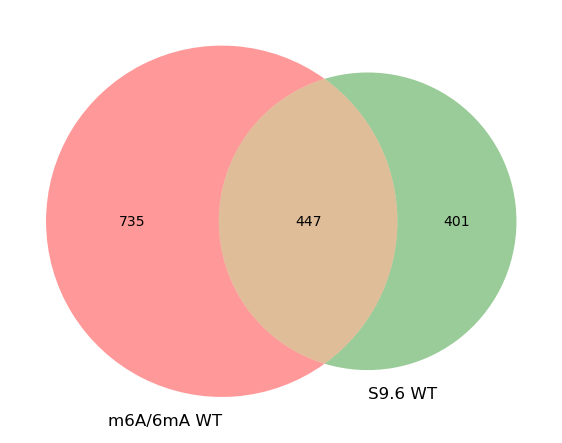

In [11]:
plt.rcParams["figure.figsize"] = [7,7]
venn2(subsets = (735, 401, 447), set_colors = ("red", "green"),
     set_labels = ("m6A/6mA WT", "S9.6 WT"))
plt.show()

_Broad peaks (WT m6A/6mA and Dam- m6A/6mA peaks)_

In [1]:
!wc -l /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/wt_m6A.bed 
# WT m6A/6mA

1182 /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/wt_m6A.bed


In [2]:
!wc -l \
/mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/DAM_min_m6A.bed
# Dam- m6A/6mA

660 /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/DAM_min_m6A.bed


In [3]:
!bedtools intersect \
-a /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/wt_m6A.bed \
-b /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/DAM_min_m6A.bed > \
/mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/intersections/wt_m6A__DAM_min_m6A_intersections.bed

In [4]:
!wc -l \
/mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/intersections/wt_m6A__DAM_min_m6A_intersections.bed

389 /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/intersections/wt_m6A__DAM_min_m6A_intersections.bed


In [5]:
1182 - 389

793

In [6]:
660 - 389

271

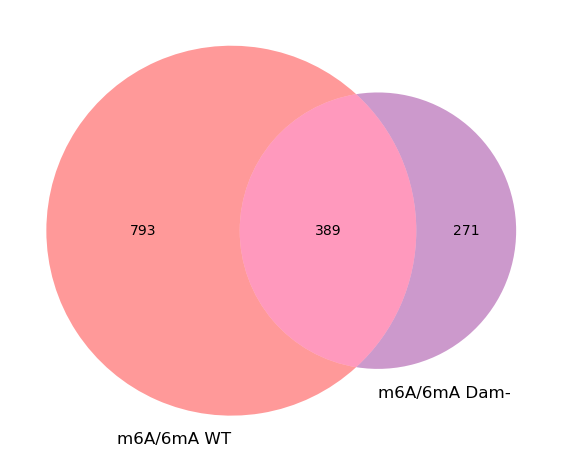

In [9]:
plt.rcParams["figure.figsize"] = [7,7]
venn2(subsets = (793, 271, 389), set_colors = ("red", "purple"),
     set_labels = ("m6A/6mA WT", "m6A/6mA Dam-"))
plt.show()

_Broad peaks (Dam- m6A/6mA peaks Dam- S9.6 peaks)_

In [11]:
!wc -l \
/mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/DAM_min_m6A.bed
# Dam- m6A/6mA

660 /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/DAM_min_m6A.bed


In [12]:
!wc -l \
/mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/DAM_min_S9_6.bed
# Dam- S9.6

583 /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/DAM_min_S9_6.bed


In [13]:
!bedtools intersect \
-a /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/DAM_min_m6A.bed \
-b /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/DAM_min_S9_6.bed > \
/mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/intersections/DAM_min_m6A__DAM_min_S9_6_intersections.bed

In [14]:
!wc -l \
/mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/intersections/DAM_min_m6A__DAM_min_S9_6_intersections.bed

378 /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/intersections/DAM_min_m6A__DAM_min_S9_6_intersections.bed


In [15]:
660 - 378

282

In [16]:
583 - 378

205

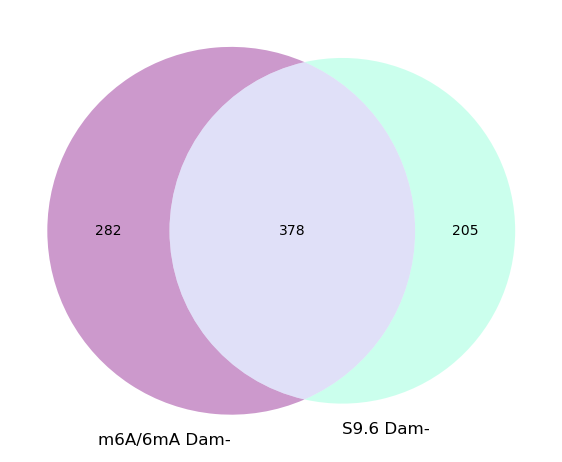

In [17]:
plt.rcParams["figure.figsize"] = [7,7]
venn2(subsets = (282, 205, 378), set_colors = ("purple", "aquamarine"),
     set_labels = ("m6A/6mA Dam-", "S9.6 Dam-"))
plt.show()

_Broad peaks (WT S9.6, Dam- S9.6 and AlkB- S9.6 peaks)_

In [11]:
!wc -l /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/wt_S96.bed
# WT S9.6

848 /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/wt_S96.bed


In [12]:
!wc -l \
/mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/DAM_min_S9_6.bed
# Dam- S9.6

583 /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/DAM_min_S9_6.bed


In [13]:
!wc -l \
/mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/AlkB_min_S9_6.bed
# AlkB- S9.6

16 /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/AlkB_min_S9_6.bed


In [14]:
!bedtools intersect \
-a /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/wt_S96.bed  \
-b /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/DAM_min_S9_6.bed > \
/mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/intersections/wt_S96__DAM_min_S96_intersections.bed

In [15]:
!wc -l /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/intersections/wt_S96__DAM_min_S96_intersections.bed

573 /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/intersections/wt_S96__DAM_min_S96_intersections.bed


In [16]:
!bedtools intersect \
-a /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/intersections/wt_S96__DAM_min_S96_intersections.bed \
-b /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/AlkB_min_S9_6.bed > \
/mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/intersections/wt_S96__DAM_min_S96__AlkB_min_S96_intersections.bed

In [17]:
!wc -l \
/mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/intersections/wt_S96__DAM_min_S96__AlkB_min_S96_intersections.bed

14 /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/intersections/wt_S96__DAM_min_S96__AlkB_min_S96_intersections.bed


In [18]:
!bedtools intersect \
-a /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/wt_S96.bed  \
-b /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/AlkB_min_S9_6.bed > \
/mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/intersections/wt_S96__AlkB_min_S96_intersections.bed

In [19]:
!wc -l \
/mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/intersections/wt_S96__AlkB_min_S96_intersections.bed

14 /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/intersections/wt_S96__AlkB_min_S96_intersections.bed


In [20]:
!bedtools intersect \
-a /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/DAM_min_S9_6.bed  \
-b /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/AlkB_min_S9_6.bed > \
/mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/intersections/DAM_min_S96__AlkB_min_S96_intersections.bed

In [21]:
!wc -l \
/mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/intersections/DAM_min_S96__AlkB_min_S96_intersections.bed

14 /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/intersections/DAM_min_S96__AlkB_min_S96_intersections.bed


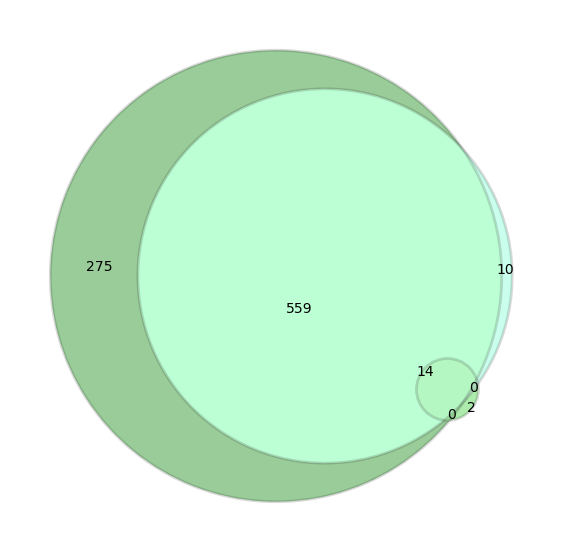

In [61]:
plt.rcParams["figure.figsize"] = [7, 7]
venn3(subsets = (275, 10, 559, 2, 0, 0, 14),
     set_labels = None, # ("S9.6 WT peaks", "S9.6 Dam- peaks", "S9.6 AlkB- peaks")
     set_colors = ("green", "aquamarine", "limegreen"))
venn3_circles(subsets=(275, 10, 559, 2, 0, 0, 14), alpha=0.15) 
plt.show()

_Broad peaks (WT m6A/6mA, Dam- m6A/6mA and AlkB- m6A/6mA peaks)_

In [2]:
!wc -l /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/wt_m6A.bed 
# WT m6A/6mA

1182 /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/wt_m6A.bed


In [3]:
!wc -l \
/mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/DAM_min_m6A.bed
# Dam- m6A/6mA

660 /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/DAM_min_m6A.bed


In [20]:
!wc -l \
/mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/AlkB_min_m6A.bed
# AlkB- m6A/6mA

566 /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/AlkB_min_m6A.bed


In [21]:
!wc -l \
/mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/intersections/wt_m6A__AlkB_min_m6A_intersections.bed

503 /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/intersections/wt_m6A__AlkB_min_m6A_intersections.bed


In [22]:
!bedtools intersect \
-a /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/intersections/wt_m6A__AlkB_min_m6A_intersections.bed  \
-b /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/DAM_min_m6A.bed > \
/mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/intersections/wt_m6A__DAM_min_m6A__AlkB_min_m6A_intersections.bed

In [23]:
!wc -l \
/mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/intersections/wt_m6A__DAM_min_m6A__AlkB_min_m6A_intersections.bed

55 /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/intersections/wt_m6A__DAM_min_m6A__AlkB_min_m6A_intersections.bed


In [24]:
!wc -l \
/mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/intersections/wt_m6A__DAM_min_m6A_intersections.bed

389 /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/intersections/wt_m6A__DAM_min_m6A_intersections.bed


In [25]:
!bedtools intersect \
-a /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/DAM_min_m6A.bed  \
-b /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/AlkB_min_m6A.bed > \
/mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/intersections/DAM_min_m6A__AlkB_min_m6A_intersections.bed

In [26]:
!wc -l \
/mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/intersections/DAM_min_m6A__AlkB_min_m6A_intersections.bed

56 /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/intersections/DAM_min_m6A__AlkB_min_m6A_intersections.bed


In [31]:
566 - 448 - 55 - 1

62

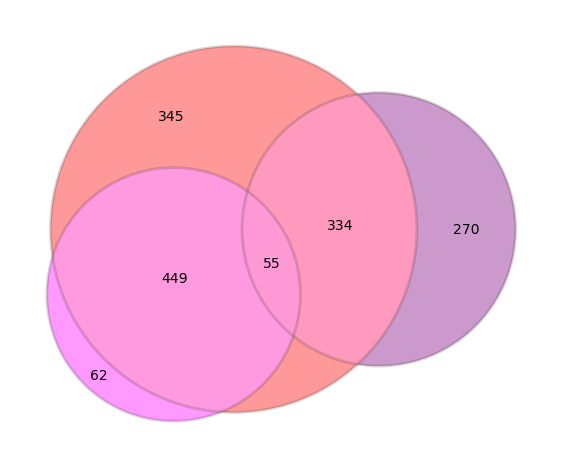

In [33]:
plt.rcParams["figure.figsize"] = [7, 7]
venn3(subsets = (345,270,334,62,449,1,55),
     set_labels = None, # ("S9.6 WT peaks", "S9.6 Dam- peaks", "S9.6 AlkB- peaks")
     set_colors = ("red", "purple", "magenta"))
venn3_circles(subsets=(345,270,334,62,449,1,55), alpha=0.15) 
plt.show()

**Heatmaps of reads density distribution**

In [20]:
!wc -l /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/wt_S96.bed
# S9.6

848 /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/wt_S96.bed


In [21]:
!bedtools subtract -A \
-a /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/wt_S96.bed \
-b /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/wt_m6A.bed \
> /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/intersections/wt_S96_only.bed

In [22]:
!wc -l \
/mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/intersections/wt_S96_only.bed
# S9.6 only

447 /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/intersections/wt_S96_only.bed


In [23]:
!mkdir /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/heatmaps

**Bigwig files creation**

In [ ]:
!mkdir \
/mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/bw

In [1]:
!cd /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/ && \
ls *_aln.bam

AlkB_min_E_Coli_aln.bam  DAM_min_E_Coli_aln.bam  wt_E_Coli_aln.bam
AlkB_min_m6A_1_aln.bam	 DAM_min_m6A_1_aln.bam	 wt_m6A_1_aln.bam
AlkB_min_m6A_2_aln.bam	 DAM_min_m6A_2_aln.bam	 wt_m6A_2_aln.bam
AlkB_min_S9_6_1_aln.bam  DAM_min_S9_6_1_aln.bam  wt_S96_1_aln.bam
AlkB_min_S9_6_2_aln.bam  DAM_min_S9_6_2_aln.bam  wt_S96_2_aln.bam


In [ ]:
!bamCoverage \
--bam /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/wt_E_Coli_aln.bam \
--outFileName /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/bw/wt_E_Coli_aln.bw \
--outFileFormat bigwig \
--effectiveGenomeSize 4641652 \
--normalizeUsing RPGC

In [ ]:
!bamCoverage \
--bam /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/wt_m6A_1_aln.bam \
--outFileName /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/bw/wt_m6A_1_aln.bw \
--outFileFormat bigwig \
--effectiveGenomeSize 4641652 \
--normalizeUsing RPGC

In [ ]:
!bamCoverage \
--bam /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/wt_S96_1_aln.bam \
--outFileName /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/bw/wt_S96_1_aln.bw \
--outFileFormat bigwig \
--effectiveGenomeSize 4641652 \
--normalizeUsing RPGC

In [32]:
# 6mA/m6A WT and 6mA/m6A WT RNase H and
# S9.6 WT and S9.6 WT RNase H and Control reads vs
# S9.6 WT peaks and S9.6 WT only peaks
!computeMatrix reference-point \
--referencePoint center \
-S /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/bw/wt_m6A_1_aln.bw \
/mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/bw/wt_m6A_RH_1_aln.bw \
/mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/bw/wt_S96_1_aln.bw \
/mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/bw/wt_S9_6_RH_1_aln.bw \
/mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/bw/wt_E_Coli_aln.bw \
-R /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/wt_S96.bed \
/mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/intersections/wt_S96_only.bed \
--beforeRegionStartLength 1500 \
--afterRegionStartLength 1500 \
-o /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/heatmaps/peaks_matrix_centering.mat.gz -p 8

In [33]:
!plotHeatmap -m /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/heatmaps/peaks_matrix_centering.mat.gz \
-out /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/heatmaps/peaks_matrix_centering.png \
--colorMap 'Reds' 'Reds' 'Greens' 'Greens' 'Greys'

In [34]:
!plotProfile -m /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/heatmaps/peaks_matrix_centering.mat.gz \
-out /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/heatmaps/peaks_matrix_centering_profile.png \
--plotType fill \
--colors forestgreen aquamarine

In [ ]:
conda install bioconda::bedops
# to use gff2bed

In [ ]:
# convert gff3 to bed
# gff3 is retrieved from: 
# https://www.ncbi.nlm.nih.gov/nuccore/U00096.3/
# and saved as 'ecoli_k12.gff3'
!sortBed -i ecoli_k12.gff3 | gff2bed > ecoli_k12.bed

In [ ]:
# to count for the num. of effective genome size
#conda install bioconda::ucsc-facount

In [47]:
#!faCount ecoli-k12_strain.fna
# total -> 4641652

#seq	len	A	C	G	T	N	cpg
NC_000913.3	4641652	1142742	1180091	1177437	1141382	0	346793
total	4641652	1142742	1180091	1177437	1141382	0	346793


In [ ]:
# reads vs genes
!computeMatrix scale-regions \
-S /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/bw/wt_S96_1_aln.bw \
/mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/bw/wt_E_Coli_aln.bw \
-R ecoli_k12.bed \
--beforeRegionStartLength 300 \
--regionBodyLength 500 \
--afterRegionStartLength 300 \
--skipZeros \
--missingDataAsZero \
-o /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/heatmaps/peaks_matrix_genes_part.mat.gz -p 8

In [ ]:
!plotProfile -m /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/heatmaps/peaks_matrix_genes_part.mat.gz \
-out /mnt/storage/lab12/k12/merged_files/aligned_reads/filtered_reads/macs2_broad_peaks/heatmaps/peaks_matrix_genes_profile_part.png \
--plotType fill \
--colors forestgreen grey \
--yMin 0 --yMax 5

**Genomic features annotation** (by R script 'gene_features_Ecoli_K12.R')